# 6. Diversity Analysis (Alpha & Beta)
## Import data & packages

In [1]:
# 1 - Import packages
import os
import matplotlib.pyplot as plt
import pandas as pd
import qiime2 as q2
from qiime2 import Visualization
import seaborn as sns
from scipy.stats import shapiro, kruskal, f_oneway
  
%matplotlib inline

In [2]:
# 2 - Set working directory
# The working directory should normally default to the 'scripts' folder. 
# If it doesn't, set it manually using the command below.
# os.chdir("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts")  # Adjust this path to match your folder structure.

# Verify that your working directory is the 'scripts' folder inside the main project directory (.../MicrobiomeAnalysis_TummyTribe/scripts)
cwd = os.getcwd()
if not cwd.endswith("MicrobiomeAnalysis_TummyTribe/scripts"):
    print("WARNING: The working directory is not set to the 'scripts' folder inside 'MicrobiomeAnalysis_TummyTribe'!")
    print("Current working directory:", cwd)
    print("Please set it manually using os.chdir().")
else:
    print(f"Working directory is correctly set to the 'scripts' folder (\"{cwd}\").")

Working directory is correctly set to the 'scripts' folder ("/home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/scripts").


In [22]:
# 3 - Data directories
raw_data_dir = "../data/raw"
denoised_data_dir = "../data/processed/denoising"
taxonomy_data_dir = "../data/processed/taxonomy"
diversity_data_dir = "../data/processed/diversity"
phylogeny_data_dir = "../data/processed/phylogeny"
daa_data_dir = "../data/processed/differential_abundance"
# Create the new differential abundance analysis folder

In [23]:
%%bash -s "$daa_data_dir"
mkdir -p "$1"

# 1. Data exploration: look at feature table

In [7]:
data = q2.Artifact.load(f'{denoised_data_dir}/dada2_table.qza').view(pd.DataFrame)

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [8]:
data.head()

,35ffcc3b809d667286737d79670b8de5,d46e2205f0c6ecf67b51f83d111c509c,2c982937754e6321f861027032db80f7,99deb3c5ecb022ec05609ebd1112a557,fd44d4cb468fd7dc9b3227867714ed87,2c5e87b291147c04e1b8d1c808b1aee0,c24e0e391aa836b5eae25567c7eb89ee,9908fffab7ed4f3bec44cda2f5084d49,315ca0a729f126b941ba111a16d4d97a,945184b6386c192c0066e0a98a154780,...,2bce8615134b73991ef0e14272646791,3a5317c713023cb528a3d6ea8edaf0a3,0a764c782ff16c18e0e2bde8d46d4608,74cd5ddaf80f3aabb34845c1558d1e54,98d918d67a235038cddd3e27015d9f39,f995b00628c62422bfba901c52048e10,ef500a1b2cafbc7ea19d914cc368cba0,6871fd2ae0f5548e5b16e9cdd0f767ac,919f2dcd2712ba221a695b4a98c5651c,efaa636ca54aed7c824dd9f521028c6b
SRR8115637,12850.0,12487.0,0.0,0.0,0.0,0.0,190.0,1903.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR8115646,2488.0,500.0,72.0,5071.0,0.0,901.0,1071.0,0.0,9365.0,381.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR8115666,387.0,1145.0,0.0,9942.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR8115682,5982.0,333.0,0.0,0.0,0.0,37.0,204.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR8115685,7066.0,0.0,0.0,0.0,0.0,0.0,221.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Plot the distribution of 15 samples to see if data is normally distributed seaborn's violin plot:

In [9]:
n = 15

# draw n ASVs out of the original DataFrame
data_samp = data.sample(n=n, axis=1, random_state=234)

# create a new DataFrame with three columns (sample, ASV, abundance)
col_names = {'level_0': 'sample', 'level_1': 'asv', 0: 'count'}
data_plot = data_samp.stack().reset_index().rename(columns=col_names)

# make sure the shape is correct (no. of rows should be equal to the size of our random 
# sample multiplied by number of samples)
assert data_plot.shape[0] == n * data_samp.shape[0], 'The new DataFrame has an incorrect no. of rows.'

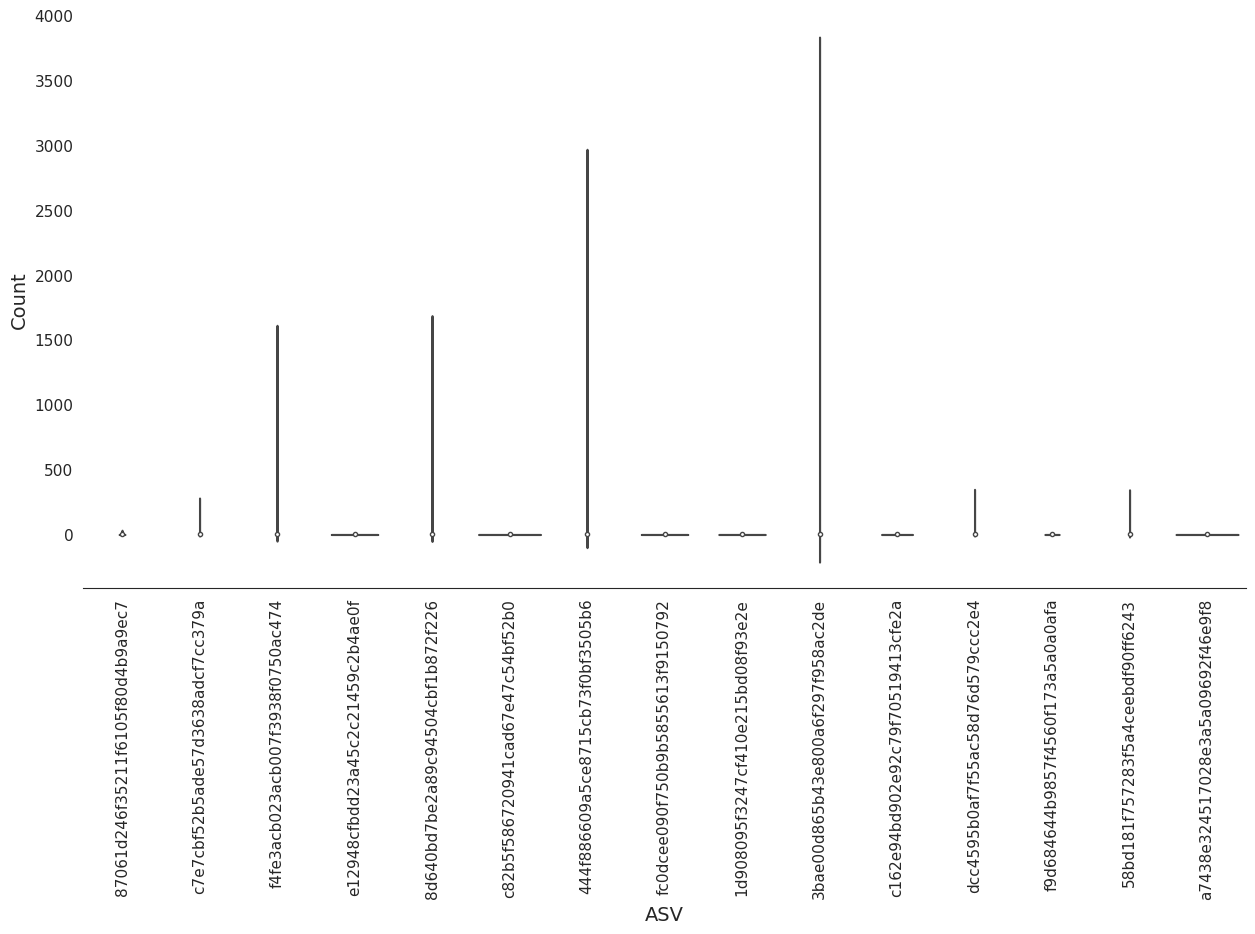

In [10]:
with sns.axes_style('white'), sns.color_palette('Set1'):
    fig, ax = plt.subplots()
    fig.set_size_inches(15, 7.5)
    
    sns.violinplot(data=data_plot, x='asv', y='count', ax=ax)
    sns.despine(left=True)
    
    # adjust tick labels and axes titles
    ax.tick_params(axis='x', rotation=90, labelsize=11)
    ax.tick_params(axis='y', labelsize=11)
    ax.set_xlabel('ASV', fontsize=14)
    ax.set_ylabel('Count', fontsize=14)

From this we can suspect that the data is not normally distributed. We can additionally check this by statistically testing for normality. 

In [11]:
alpha = 0.05
results = {}

# iterate through rows (samples) and test each of them for normality
for asv_name, asv_values in data.items():
    stat, p = shapiro(asv_values)
    results[asv_name] = p

# convert test results into a DataFrame
results_df = pd.DataFrame(data=results.values(), index=results.keys(), columns=['p'])

# add a new column with a descriptive test result
results_df['is_normal'] = results_df['p'] > alpha

In [12]:
results_df

,p,is_normal
35ffcc3b809d667286737d79670b8de5,5.141034e-33,False
d46e2205f0c6ecf67b51f83d111c509c,1.878576e-32,False
2c982937754e6321f861027032db80f7,3.512602e-33,False
99deb3c5ecb022ec05609ebd1112a557,3.600188e-32,False
fd44d4cb468fd7dc9b3227867714ed87,4.138422e-34,False
...,...,...
f995b00628c62422bfba901c52048e10,7.024117e-39,False
ef500a1b2cafbc7ea19d914cc368cba0,7.024117e-39,False
6871fd2ae0f5548e5b16e9cdd0f767ac,7.024117e-39,False
919f2dcd2712ba221a695b4a98c5651c,7.024117e-39,False


In [13]:
print('Number of ASVs with normal distribution:', results_df['is_normal'].sum())

Number of ASVs with normal distribution: 0


# 2. ANCOM – Delivery Mode

In [32]:
# create folder for delivery mode
!mkdir -p "$daa_data_dir/delivery_mode"

In [33]:
! qiime feature-table filter-features \
    --i-table $denoised_data_dir/dada2_table.qza \
    --p-min-frequency 25 \
    --p-min-samples 4 \
    --o-filtered-table $daa_data_dir/table_abund.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/differential_abundance/table_abund.qza


In [34]:
! qiime feature-table filter-samples \
    --i-table $daa_data_dir/table_abund.qza \
    --m-metadata-file $raw_data_dir/metadata.tsv \
    --p-where "[delivery_mode]='vaginal' or [delivery_mode]='cesarean'" \
    --o-filtered-table $daa_data_dir/delivery_mode/table_abund_deliverymode.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/differential_abundance/delivery_mode/table_abund_deliverymode.qza


In [35]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $daa_data_dir/delivery_mode/table_abund_deliverymode.qza \
    --m-metadata-file $raw_data_dir/metadata.tsv \
    --p-formula delivery_mode \
    --o-differentials $daa_data_dir/delivery_mode/ancombc_deliverymode_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $daa_data_dir/delivery_mode/ancombc_deliverymode_differentials.qza \
    --o-visualization $daa_data_dir/delivery_mode/ancombc_deliverymode_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $daa_data_dir/delivery_mode/ancombc_deliverymode_differentials.qza \
    --o-visualization $daa_data_dir/delivery_mode/ancombc_deliverymode_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: ../data/processed/differential_abundance/delivery_mode/ancombc_deliverymode_differentials.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/differential_abundance/delivery_mode/ancombc_deliverymode_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources 

In [ ]:
Visualization.load(f"{daa_data_dir}/delivery_mode/ancombc_deliverymode_da_barplot.qzv")

In [ ]:
Visualization.load(f"{daa_data_dir}/delivery_mode/ancombc_deliverymode_results.qzv")

We will now export the taxonomy file and the results from the ANCOM, to combine the two in a pd datframe.

In [36]:
# export differentials
! qiime tools export \
      --input-path $daa_data_dir/delivery_mode/ancombc_deliverymode_differentials.qza \
      --output-path $daa_data_dir/delivery_mode

# export taxonomy
! qiime tools export \
      --input-path $taxonomy_data_dir/taxonomy.qza \
      --output-path $taxonomy_data_dir

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/differential_abundance/delivery_mode/ancombc_deliverymode_differentials.qza as DataLoafPackageDirFmt to directory ../data/processed/differential_abundance/delivery_mode
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/taxonomy/taxonomy.qza as TSVTaxonomyDirectoryFormat to directory ../data/processed/taxonomy


In [41]:
# combine into one table
diff = pd.read_csv(f"{daa_data_dir}/delivery_mode/lfc_slice.csv", sep=",")
tax  = pd.read_csv(f"{taxonomy_data_dir}/taxonomy.tsv", sep="\t")

merged = diff.merge(tax, left_on="id", right_on="Feature ID")
merged.to_csv(f"{daa_data_dir}/delivery_mode/ancombc_with_taxonomy_deliverymode.tsv", sep="\t", index=False)

# 3. ANCOM – Diet Milk

In [ ]:
# create folder for diet
!mkdir -p "$daa_data_dir/diet"

In [ ]:
! qiime feature-table filter-samples \
    --i-table $daa_data_dir/table_abund.qza \
    --m-metadata-file $raw_data_dir/metadata.tsv \
    --p-where "[diet_milk]='bd' or [diet_milk]='fd'" \
    --o-filtered-table $daa_data_dir/diet/table_abund_diet.qza

In [ ]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $daa_data_dir/diet/table_abund_diet.qza \
    --m-metadata-file $raw_data_dir/metadata.tsv \
    --p-formula diet_milk \
    --o-differentials $daa_data_dir/diet/ancombc_diet_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $daa_data_dir/diet/ancombc_diet_differentials.qza \
    --o-visualization $daa_data_dir/diet/ancombc_deliverymode_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $daa_data_dir/diet/ancombc_deliverymode_differentials.qza \
    --o-visualization $daa_data_dir/diet/ancombc_deliverymode_results.qzv

In [ ]:
Visualization.load(f"{daa_data_dir}/diet/ancombc_diet_da_barplot.qzv")

In [ ]:
Visualization.load(f"{daa_data_dir}/diet/ancombc_diet_results.qzv")

# 4. ANCOM-BC2 analysis – Delivery Mode
Bias control and include taxonomy

In [44]:
# first we will run the ANCOM-BC2  
! qiime composition ancombc2 \
    --i-table $daa_data_dir/delivery_mode/table_abund_deliverymode.qza \
    --m-metadata-file $raw_data_dir/metadata.tsv \
    --p-fixed-effects-formula delivery_mode \
    --o-ancombc2-output $daa_data_dir/delivery_mode/ancombc2_deliverymode_output.qza

# Visualization including taxononomy
! qiime composition ancombc2-visualizer \
    --i-data $daa_data_dir/delivery_mode/ancombc2_deliverymode_output.qza \
    --i-taxonomy $taxonomy_data_dir/taxonomy.qza \
    --o-visualization $daa_data_dir/delivery_mode/ancombc2_deliverymode_vis.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[ANCOMBC2Output] to: ../data/processed/differential_abundance/delivery_mode/ancombc2_deliverymode_output.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Usage: qiime composition ancombc2-visualizer [OPTIONS]

  Displays ANCOMBC2 Log-Fold Change values in a barplot and allows filtering
  based on p-value and standard error. If a taxonomy is provided, features can
  be f

In [46]:
Visualization.load(f"{daa_data_dir}/delivery_mode/ancombc2_deliverymode_vis.qzv")

<visualization: Visualization uuid: 5e386b7b-a84a-4398-94c8-b21904a53e24>